#6 Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

Objective

In this exercise, you will build and train a Fully Connected Network (FCN) to classify Devnagari digits
using TensorFlow and Keras. You will manually load and process the dataset using the Python Imaging
Library (PIL) and then train the model with three hidden layers.

##Task 1: Data Preparation
Loading the Data

* Download the provided folder that contains the Devnagari digits dataset.
* Use the Python Imaging Library (PIL) to load and read the image files from the dataset.
* Convert the images into Numpy arrays and normalize them to a range of 0-1.
* use train folder for training and test for testing.
* Extract the corresponding labels for each image.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

In [23]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28,28)
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


In [24]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/Dataset/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/Dataset/DevanagariHandwrittenDigitDataset/Test/"

# defining image shape
img_height, img_width = 28, 28

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


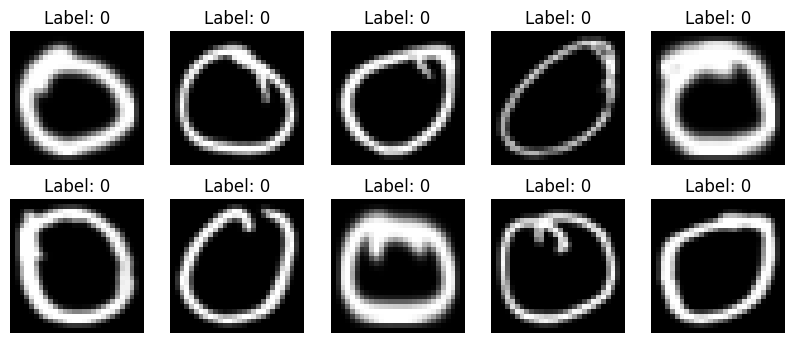

In [25]:
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

##Task 2: Build the FCN Model
Model Architecture
* Create a Sequential model using Keras.
* Add 3 hidden layers with the following number of neurons:

  – 1st hidden layer: 64 neurons

  – 2nd hidden layer: 128 neurons

  – 3rd hidden layer: 256 neurons

* Use sigmoid activation functions for all hidden layers.
* Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a softmax activation function.

In [38]:
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

##Task 3: Compile the Model
Model Compilation
* Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [39]:
model.compile(
optimizer="sgd", # Stochastic Gradient Descent
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

##Task 4: Train the Model
Model Training
* Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.
* Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.
* Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [40]:
batch_size = 128
epochs = 20
# Callbacks
callbacks = [
keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
x_train,
y_train,
batch_size=batch_size,
epochs=epochs,
validation_split=0.2,
callbacks=callbacks,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1271 - loss: 2.1588 - val_accuracy: 0.0000e+00 - val_loss: 4.5936
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1288 - loss: 2.0936 - val_accuracy: 0.0000e+00 - val_loss: 5.2749
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1310 - loss: 2.0870 - val_accuracy: 0.0000e+00 - val_loss: 5.6779
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1309 - loss: 2.0838 - val_accuracy: 0.0000e+00 - val_loss: 5.9660
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1379 - loss: 2.0814 - val_accuracy: 0.0000e+00 - val_loss: 6.1905


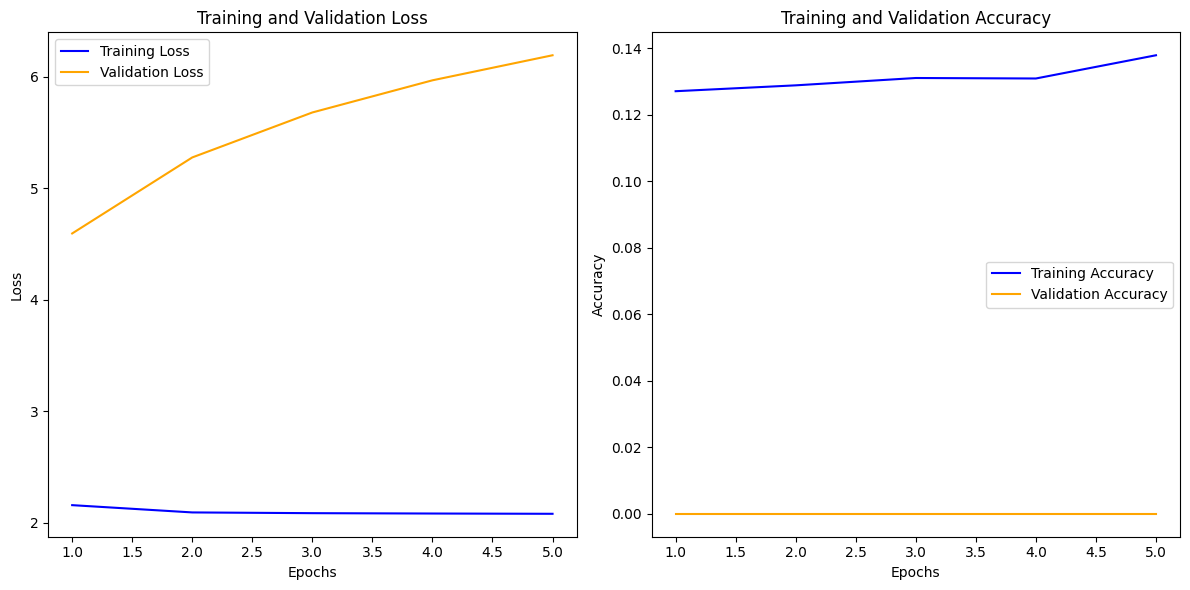

In [41]:
# Assuming 'history' is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

##Task 5: Evaluate the Model
Model Evaluation
* After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [30]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.1000 - loss: 2.8986
Test accuracy: 0.1000


##Task 6: Save and Load the Model
Model Saving and Loading
* Save the trained model to an .h5 file using model.save().
* Load the saved model and re-evaluate its performance on the test set.

In [34]:
model.save("/content/drive/MyDrive/Week1LastSem/mnist_fully_connected_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [35]:
loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Week1LastSem/mnist_fully_connected_model.h5"
)
print("Model loaded successfully!")

Model loaded successfully!


In [36]:
loss, accuracy = loaded_model.evaluate(x_test, y_test)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1000 - loss: 2.8986
Test Loss: 2.898594379425049
Test Accuracy: 0.10000000149011612


##Task 7: Predictions
Making Predictions
* Use model.predict() to make predictions on test images.
* Convert the model’s predicted probabilities to digit labels using np.argmax().

In [37]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 4
True label for first image: 0
